In [1]:
import kagglehub
from os import getcwd
import shutil

In [2]:
path = kagglehub.dataset_download(
    "sbhatti/financial-sentiment-analysis")
shutil.copytree(path, getcwd(), dirs_exist_ok=True)

100%|██████████| 276k/276k [00:00<00:00, 19.5MB/s]

Extracting files...


'/content'

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("data.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5842 entries, 0 to 5841
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentence   5842 non-null   object
 1   Sentiment  5842 non-null   object
dtypes: object(2)
memory usage: 91.4+ KB


In [6]:
df.head()

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


In [7]:
df["Sentiment"].value_counts(normalize=True) * 100

,proportion
Sentiment,
neutral,53.577542
positive,31.701472
negative,14.720986


In [8]:
df.duplicated().sum()

np.int64(6)

In [9]:
df[df.duplicated(keep=False)].sort_values(
    df.columns.tolist()).to_csv("duplicate.csv", index=False)

In [10]:
content_stat_df = pd.DataFrame()

In [11]:
content_stat_df["word_count"] = df["Sentence"].str.split().str.len()

content_stat_df["char_count"] = df["Sentence"].str.len()

In [12]:
content_stat_df.describe()

,word_count,char_count
count,5842.000000,5842.000000
mean,21.004793,117.022253
std,10.306465,56.420425
min,2.000000,9.000000
25%,13.000000,72.000000
50%,19.000000,107.000000
75%,27.000000,150.000000
max,81.000000,315.000000


In [13]:
df = df.drop_duplicates().reset_index(drop=True)

In [14]:
df.duplicated().sum()

np.int64(0)

### URL check

In [15]:
df["Sentence"].str.contains(r"http|www", regex=True).sum()

np.int64(279)

In [16]:
df[df["Sentence"].str.contains(r"http|www", regex=True)].to_csv("urls.csv", index=False)

### HTML tag basic regex based check

In [17]:
df["Sentence"].str.contains(r"<.*?>", regex=True).sum()

np.int64(1)

In [18]:
df[df["Sentence"].str.contains(
    r"<.*?>", regex=True)].to_csv("html.csv", index=False)

### email address basic regex based check

In [19]:
df["Sentence"].str.contains(
    r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b",
    regex=True
).sum()

np.int64(0)

In [20]:
df["Sentence"].sample(20, random_state=42).to_csv("random_sample.csv", index=False)

In [21]:
import re

In [22]:
df["Sentence"] = df["Sentence"].str.replace(
    r"http\S+|www\S+|https\S+",
    "",
    regex=True
).str.strip()

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X = df["Sentence"]
y = df["Sentiment"]

In [25]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [26]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(4085,)
(875,)
(876,)


In [27]:
print(y_train.value_counts(normalize=True))
print(y_val.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Sentiment
neutral     0.535373
positive    0.317258
negative    0.147368
Name: proportion, dtype: float64
Sentiment
neutral     0.534857
positive    0.317714
negative    0.147429
Name: proportion, dtype: float64
Sentiment
neutral     0.535388
positive    0.317352
negative    0.147260
Name: proportion, dtype: float64


In [28]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [29]:
lr_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=False
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

In [30]:
lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(lowercase=False)),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [31]:
y_val_pred = lr_pipeline.predict(X_val)
y_test_pred = lr_pipeline.predict(X_test)

In [32]:
y_val_prob = lr_pipeline.predict_proba(X_val)
y_test_prob = lr_pipeline.predict_proba(X_test)

In [33]:
# X_train_tfidf = lr_pipeline.named_steps["tfidf"].transform(X_train)
# X_val_tfidf = lr_pipeline.named_steps["tfidf"].transform(X_val)
# X_test_tfidf = lr_pipeline.named_steps["tfidf"].transform(X_test)

In [34]:
feature_names = lr_pipeline.named_steps["tfidf"].get_feature_names_out()

print("Vocabulary size:", len(feature_names))
print(feature_names[1800:2000])

Vocabulary size: 10631
['ERO' 'ERP' 'ES' 'ESI' 'ESL' 'ESPN' 'ES_F' 'ETE' 'ETN' 'EU' 'EUA' 'EUR'
 'EUR0' 'EUR1' 'EUR10' 'EUR106' 'EUR107' 'EUR108' 'EUR11' 'EUR111'
 'EUR1149' 'EUR11m' 'EUR12' 'EUR120m' 'EUR121m' 'EUR127' 'EUR13' 'EUR131m'
 'EUR139m' 'EUR14' 'EUR143' 'EUR15' 'EUR150m' 'EUR152' 'EUR155' 'EUR156'
 'EUR157' 'EUR159' 'EUR15m' 'EUR16' 'EUR160m' 'EUR16m' 'EUR17' 'EUR179'
 'EUR17m' 'EUR18' 'EUR182' 'EUR19' 'EUR193' 'EUR196' 'EUR1bn' 'EUR2'
 'EUR20' 'EUR20m' 'EUR21' 'EUR21m' 'EUR22' 'EUR23' 'EUR25' 'EUR250m'
 'EUR25m' 'EUR26' 'EUR27' 'EUR27m' 'EUR28' 'EUR29' 'EUR297' 'EUR29m'
 'EUR2m' 'EUR3' 'EUR30' 'EUR300' 'EUR30m' 'EUR32' 'EUR320' 'EUR33m'
 'EUR342' 'EUR35' 'EUR36m' 'EUR38' 'EUR386' 'EUR394' 'EUR39m' 'EUR3m'
 'EUR4' 'EUR400m' 'EUR40m' 'EUR415' 'EUR416' 'EUR41m' 'EUR42' 'EUR42m'
 'EUR43' 'EUR45m' 'EUR46' 'EUR46m' 'EUR47' 'EUR5' 'EUR510m' 'EUR55'
 'EUR550m' 'EUR58' 'EUR582' 'EUR58m' 'EUR59' 'EUR598' 'EUR5m' 'EUR6'
 'EUR609m' 'EUR61' 'EUR61m' 'EUR63' 'EUR634' 'EUR64' 'EUR65' 'EU

In [35]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)
import matplotlib.pyplot as plt

In [36]:
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy:.4f}")

Validation Accuracy: 0.6937


In [37]:
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

    negative       0.38      0.12      0.18       129
     neutral       0.70      0.88      0.78       468
    positive       0.73      0.65      0.69       278

    accuracy                           0.69       875
   macro avg       0.60      0.55      0.55       875
weighted avg       0.66      0.69      0.66       875



In [38]:
auc = roc_auc_score(
    y_val,
    y_val_prob,
    multi_class="ovr",
    average="macro"
)

print(f"Validation ROC-AUC (OvR): {auc:.4f}")

Validation ROC-AUC (OvR): 0.8242


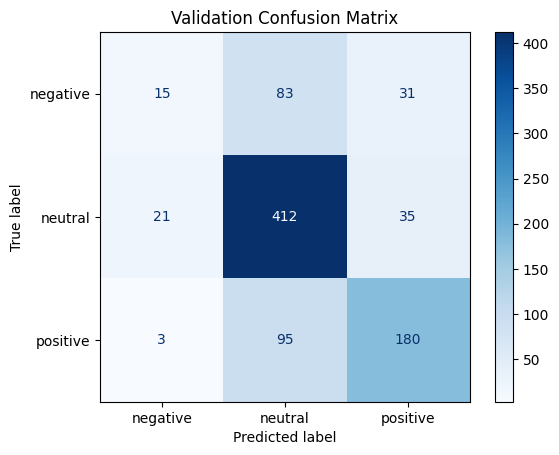

In [39]:
cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=lr_pipeline.named_steps["classifier"].classes_
)

disp.plot(cmap="Blues")
plt.title("Validation Confusion Matrix")
plt.show()

In [40]:
balanced_lr_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=False
        )
    ),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        )
    )
])

In [41]:
balanced_lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(lowercase=False)),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [42]:
y_val_pred = balanced_lr_pipeline.predict(X_val)
y_test_pred = balanced_lr_pipeline.predict(X_test)

In [43]:
y_val_prob = balanced_lr_pipeline.predict_proba(X_val)
y_test_prob = balanced_lr_pipeline.predict_proba(X_test)

In [44]:
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

    negative       0.40      0.46      0.43       129
     neutral       0.78      0.73      0.75       468
    positive       0.70      0.73      0.72       278

    accuracy                           0.69       875
   macro avg       0.63      0.64      0.63       875
weighted avg       0.70      0.69      0.70       875



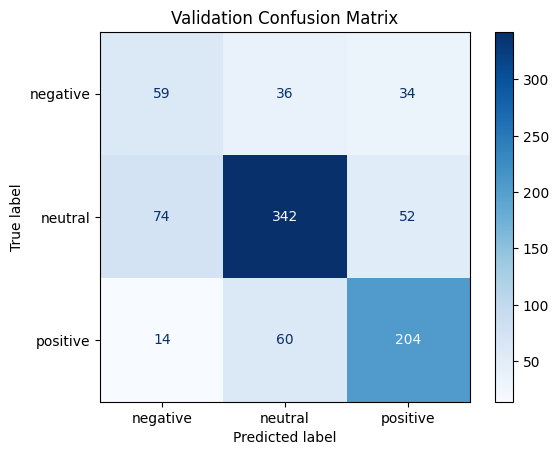

In [45]:
cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=balanced_lr_pipeline.named_steps["classifier"].classes_
)

disp.plot(cmap="Blues")
plt.title("Validation Confusion Matrix")
plt.show()

In [46]:
balanced_feature_names = balanced_lr_pipeline.named_steps["tfidf"].get_feature_names_out()

print("Vocabulary size:", len(feature_names))
print(feature_names[1800:2000])

Vocabulary size: 10631
['ERO' 'ERP' 'ES' 'ESI' 'ESL' 'ESPN' 'ES_F' 'ETE' 'ETN' 'EU' 'EUA' 'EUR'
 'EUR0' 'EUR1' 'EUR10' 'EUR106' 'EUR107' 'EUR108' 'EUR11' 'EUR111'
 'EUR1149' 'EUR11m' 'EUR12' 'EUR120m' 'EUR121m' 'EUR127' 'EUR13' 'EUR131m'
 'EUR139m' 'EUR14' 'EUR143' 'EUR15' 'EUR150m' 'EUR152' 'EUR155' 'EUR156'
 'EUR157' 'EUR159' 'EUR15m' 'EUR16' 'EUR160m' 'EUR16m' 'EUR17' 'EUR179'
 'EUR17m' 'EUR18' 'EUR182' 'EUR19' 'EUR193' 'EUR196' 'EUR1bn' 'EUR2'
 'EUR20' 'EUR20m' 'EUR21' 'EUR21m' 'EUR22' 'EUR23' 'EUR25' 'EUR250m'
 'EUR25m' 'EUR26' 'EUR27' 'EUR27m' 'EUR28' 'EUR29' 'EUR297' 'EUR29m'
 'EUR2m' 'EUR3' 'EUR30' 'EUR300' 'EUR30m' 'EUR32' 'EUR320' 'EUR33m'
 'EUR342' 'EUR35' 'EUR36m' 'EUR38' 'EUR386' 'EUR394' 'EUR39m' 'EUR3m'
 'EUR4' 'EUR400m' 'EUR40m' 'EUR415' 'EUR416' 'EUR41m' 'EUR42' 'EUR42m'
 'EUR43' 'EUR45m' 'EUR46' 'EUR46m' 'EUR47' 'EUR5' 'EUR510m' 'EUR55'
 'EUR550m' 'EUR58' 'EUR582' 'EUR58m' 'EUR59' 'EUR598' 'EUR5m' 'EUR6'
 'EUR609m' 'EUR61' 'EUR61m' 'EUR63' 'EUR634' 'EUR64' 'EUR65' 'EU

In [47]:
import nltk
from nltk.corpus import stopwords

In [48]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [49]:
stop_words = set(stopwords.words("english"))

In [50]:
lr = lr_pipeline.named_steps["classifier"]
coef = lr.coef_
coef.shape

(3, 10631)

In [51]:
negative_idx = list(lr.classes_).index("negative")

negative_words = pd.DataFrame({
    "word": balanced_feature_names,
    "weight": coef[negative_idx]
}).sort_values("weight", ascending=False)

negative_words.head(30)

,word,weight
6689,down,3.430739
6477,decreased,2.083503
8021,lower,1.975721
7076,fell,1.799663
4707,TSLA,1.787403
9551,short,1.341755
7033,fall,1.333440
8409,off,1.278767
6431,cut,1.274863
7791,jobs,1.170748


In [52]:
neutral_idx = list(lr.classes_).index("neutral")

neutral_words = pd.DataFrame({
    "word": balanced_feature_names,
    "weight": coef[neutral_idx]
}).sort_values("weight", ascending=False)

neutral_words.head(30)

,word,weight
7769,is,2.874105
4809,The,2.664323
5475,and,2.110924
8406,of,1.824359
10507,will,1.808182
5530,approximately,1.506603
10057,the,1.369344
7605,includes,1.338430
5678,be,1.322183
10476,were,1.271532


In [53]:
positive_idx = list(lr.classes_).index("positive")

positive_words = pd.DataFrame({
    "word": balanced_feature_names,
    "weight": coef[positive_idx]
}).sort_values("weight", ascending=False)

positive_words.head(30)

,word,weight
9338,rose,3.396812
10300,up,3.024886
7613,increase,2.847060
7614,increased,2.600077
8764,positive,2.029306
7353,grew,1.967100
9577,signed,1.923198
3099,Long,1.757188
5619,awarded,1.613640
9310,rise,1.519406


In [54]:
top_n = 50

important_words = set()

important_words.update(positive_words.head(top_n)["word"])
important_words.update(neutral_words.head(top_n)["word"])
important_words.update(negative_words.head(top_n)["word"])

print("Number of unique important words:", len(important_words))

Number of unique important words: 148


In [55]:
important_stopwords = important_words.intersection(stop_words)

print(sorted(important_stopwords))

['an', 'and', 'any', 'are', 'be', 'below', 'down', 'from', 'if', 'is', 'more', 'no', 'not', 'of', 'off', 'or', 'other', 'our', 'than', 'the', 'to', 'up', 'very', 'was', 'were', 'will', 'won']


In [56]:
custom_stopwords = stop_words - important_stopwords

print("Original stopwords :", len(stop_words))
print("Custom stopwords   :", len(custom_stopwords))

Original stopwords : 198
Custom stopwords   : 171


In [57]:
stopward_lr_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=False,
            stop_words=list(custom_stopwords)
        )
    ),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        )
    )
])

In [58]:
stopward_lr_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['won'] not in stop_words.
  warnings.warn(


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(lowercase=False,
                                 stop_words=["doesn't", 'because', 'they',
                                             "shouldn't", "i'm", 'itself',
                                             'then', 'hasn', 'why', 'where',
                                             "she'll", 'as', "weren't", 'wasn',
                                             'few', 'myself', 'm', 'had', 'too',
                                             'how', 'doesn', 'above', 've',
                                             'didn', 'against', 't', 'them',
                                             'me', 'we', 'haven', ...])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [59]:
y_val_pred = stopward_lr_pipeline.predict(X_val)
y_test_pred = stopward_lr_pipeline.predict(X_test)

In [60]:
y_val_prob = stopward_lr_pipeline.predict_proba(X_val)
y_test_prob = stopward_lr_pipeline.predict_proba(X_test)

In [61]:
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

    negative       0.41      0.47      0.43       129
     neutral       0.77      0.72      0.75       468
    positive       0.70      0.72      0.71       278

    accuracy                           0.69       875
   macro avg       0.62      0.64      0.63       875
weighted avg       0.69      0.69      0.69       875



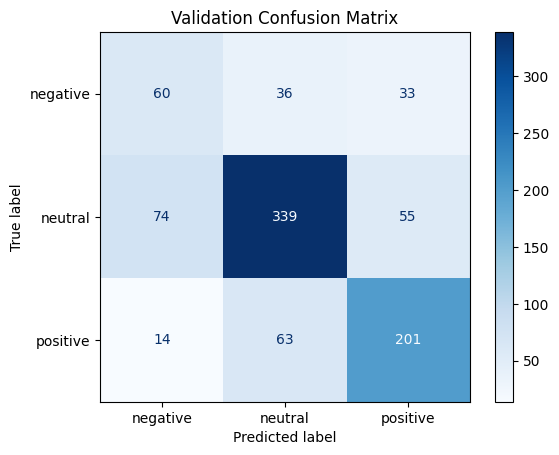

In [62]:
cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=stopward_lr_pipeline.named_steps["classifier"].classes_
)

disp.plot(cmap="Blues")
plt.title("Validation Confusion Matrix")
plt.show()

In [63]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    SimpleRNN,
    Dense,
    Dropout,
    LSTM, 
    Activation
)

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import LabelEncoder

In [64]:
label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

In [65]:
VOCAB_SIZE = 11000

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

In [66]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [67]:
print(X_train.iloc[0])
print(X_train_seq[0])

FTSE 100 falls as China devaluation hits Burberry, mining stocks
[423, 221, 1166, 17, 243, 4645, 3163, 4646, 1167, 512]


In [68]:
train_lengths = [len(seq) for seq in X_train_seq]

print(f"Minimum length : {min(train_lengths)}")
print(f"Maximum length : {max(train_lengths)}")
print(f"Average length : {np.mean(train_lengths):.2f}")
print(f"Median length  : {np.median(train_lengths):.2f}")

Minimum length : 1
Maximum length : 53
Average length : 19.60
Median length  : 18.00


In [69]:
for p in [50, 75, 90, 95, 99, 100]:
    print(f"{p:>3}th percentile: {np.percentile(train_lengths, p):.0f}")

 50th percentile: 18
 75th percentile: 25
 90th percentile: 33
 95th percentile: 38
 99th percentile: 45
100th percentile: 53


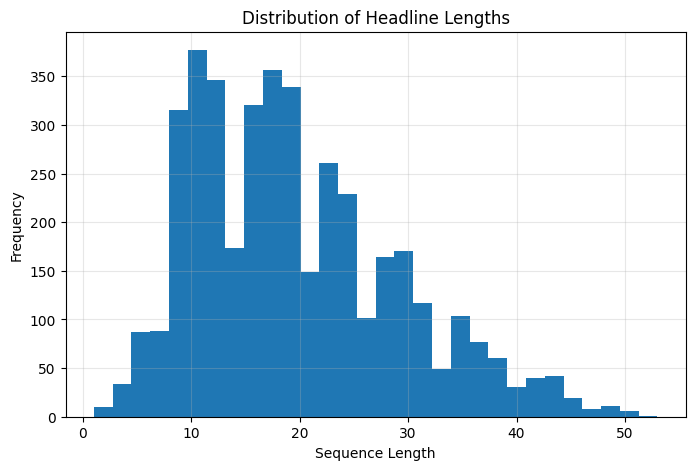

In [70]:
plt.figure(figsize=(8, 5))
plt.hist(train_lengths, bins=30)
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.title("Distribution of Headline Lengths")
plt.grid(alpha=0.3)
plt.show()

In [71]:
MAX_LENGTH = 45

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

In [72]:
print(X_train_pad.shape)
print(X_val_pad.shape)
print(X_test_pad.shape)

(4085, 45)
(875, 45)
(876, 45)


In [73]:
simple_dl_model = Sequential([
    Input(shape=(MAX_LENGTH,)),
    Dense(4),
    Activation('relu'),
    Dropout(0.2),
    Dense(32),
    Activation('relu'),
    Dropout(0.5),
    Dense(3),
    Activation('sigmoid')
])

In [74]:
simple_dl_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [75]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [76]:
history = simple_dl_model.fit(
    X_train_pad,
    y_train_enc,
    validation_data=(X_val_pad, y_val_enc),
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3288 - loss: 242.5708 - val_accuracy: 0.4537 - val_loss: 36.1543
Epoch 2/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4494 - loss: 63.9064 - val_accuracy: 0.5246 - val_loss: 17.3852
Epoch 3/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4803 - loss: 26.7480 - val_accuracy: 0.5246 - val_loss: 10.0318
Epoch 4/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5038 - loss: 14.2518 - val_accuracy: 0.5360 - val_loss: 6.5698
Epoch 5/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5072 - loss: 8.5654 - val_accuracy: 0.5360 - val_loss: 4.3861
Epoch 6/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5187 - loss: 5.0046 - val_accuracy: 0.5326 - val_loss: 3.1859
Epoch 7/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5217 - loss: 3.4800 - val_accuracy: 0.5326 - val_loss: 2.5306
Epoch 8/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5226 - loss: 3.2368 - val_accu

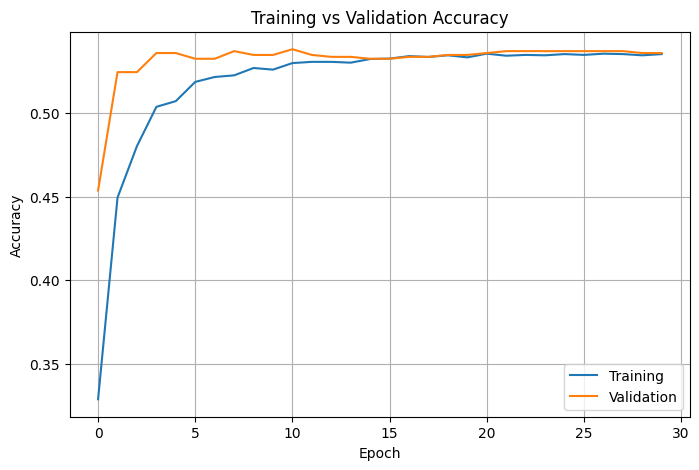

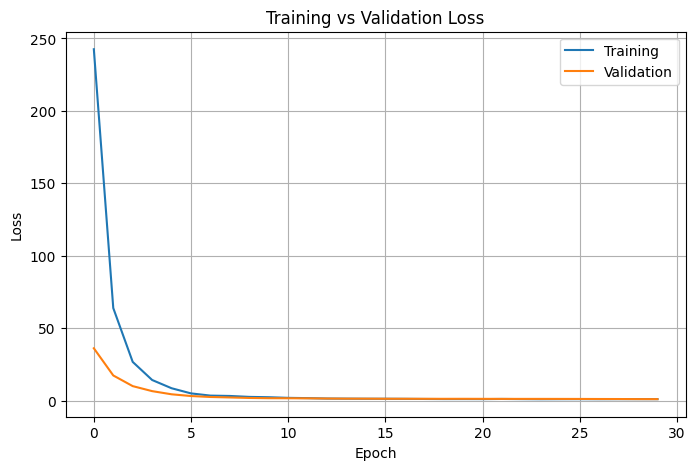

In [77]:
# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [78]:
EMBEDDING_DIM = 50


rnn_model = Sequential([
    Input(shape=(MAX_LENGTH,)),
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),
    SimpleRNN(32),
    Dropout(0.5),
    Dense(32, activation="relu"),
    Dense(3, activation="softmax")
])

In [79]:
rnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [80]:
rnn_history = rnn_model.fit(
    X_train_pad,
    y_train_enc,
    validation_data=(X_val_pad, y_val_enc),
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.5168 - loss: 1.0036 - val_accuracy: 0.5303 - val_loss: 0.9967
Epoch 2/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5491 - loss: 0.9602 - val_accuracy: 0.5429 - val_loss: 0.9818
Epoch 3/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6573 - loss: 0.8173 - val_accuracy: 0.5623 - val_loss: 1.0046
Epoch 4/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.7606 - loss: 0.6209 - val_accuracy: 0.5337 - val_loss: 1.1360
Epoch 5/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8203 - loss: 0.4565 - val_accuracy: 0.5029 - val_loss: 1.3047


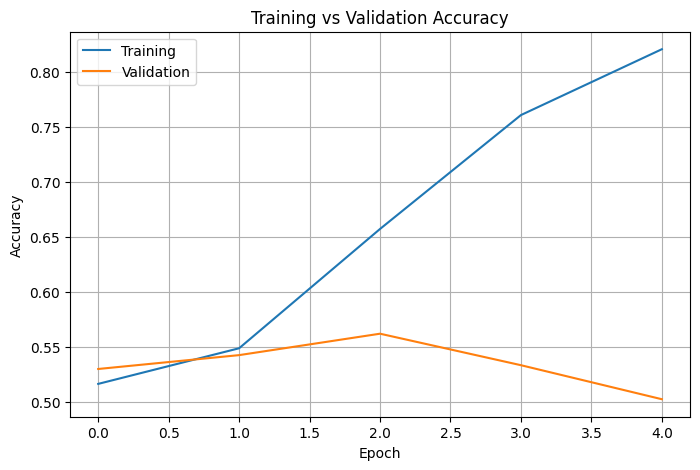

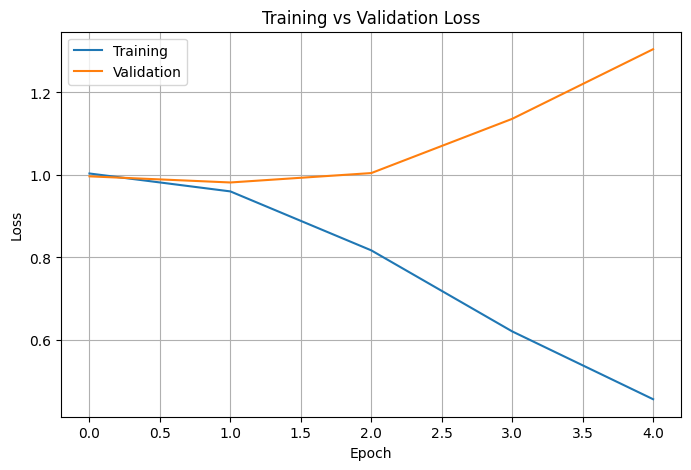

In [81]:
# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(rnn_history.history["accuracy"], label="Training")
plt.plot(rnn_history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8, 5))
plt.plot(rnn_history.history["loss"], label="Training")
plt.plot(rnn_history.history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [82]:
EMBEDDING_DIM = 50


rnn_model_2 = Sequential([
    Input(shape=(MAX_LENGTH,)),
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),
    SimpleRNN(32, dropout=0.3, recurrent_dropout=0.3),
    Dropout(0.5),
    Dense(32, activation="relu"),
    Dense(3, activation="softmax")
])

In [83]:
rnn_model_2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [84]:
rnn_history_2 = rnn_model_2.fit(
    X_train_pad,
    y_train_enc,
    validation_data=(X_val_pad, y_val_enc),
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.4428 - loss: 1.0954 - val_accuracy: 0.5349 - val_loss: 1.0051
Epoch 2/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.4982 - loss: 1.0181 - val_accuracy: 0.5349 - val_loss: 0.9971
Epoch 3/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5217 - loss: 1.0034 - val_accuracy: 0.5349 - val_loss: 1.0069


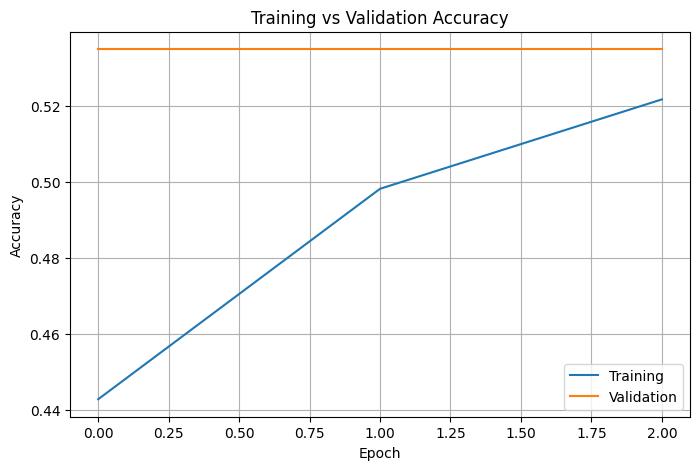

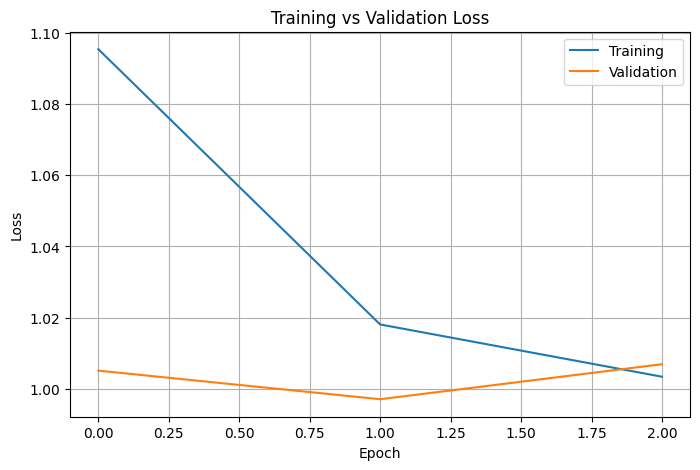

In [85]:
# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(rnn_history_2.history["accuracy"], label="Training")
plt.plot(rnn_history_2.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8, 5))
plt.plot(rnn_history_2.history["loss"], label="Training")
plt.plot(rnn_history_2.history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [131]:
from sklearn.model_selection import GridSearchCV

In [140]:
lr_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=False
        )
    ),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )
    )
])

In [141]:
param_grid = {
    # TF-IDF parameters
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2, 5],
    "tfidf__max_df": [0.90, 0.95, 1.0],

    # Logistic Regression parameters
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__solver": ["lbfgs", "saga"]
}

grid = GridSearchCV(
    lr_pipeline,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2,
    refit=True
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(lowercase=False)),
                                       ('classifier',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=2000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10],
                         'classifier__solver': ['lbfgs', 'saga'],
                         'tfidf__max_df': [0.9, 0.95, 1.0],
                         'tfidf__min_df': [1, 2, 5],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='f1_macro', verbose=2)

In [142]:
print(grid.best_params_)
print(grid.best_score_)

{'classifier__C': 1, 'classifier__solver': 'lbfgs', 'tfidf__max_df': 0.9, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}
0.6424084176114498


In [143]:
lr_pipeline_final = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=False,
            max_df=0.9,
            ngram_range=(1,1)
        )
    ),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )
    )
])

In [144]:
lr_pipeline_final.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(lowercase=False, max_df=0.9)),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

In [145]:
y_val_pred = lr_pipeline_final.predict(X_val)
y_test_pred = lr_pipeline_final.predict(X_test)

In [146]:
y_val_prob = lr_pipeline_final.predict_proba(X_val)
y_test_prob = lr_pipeline_final.predict_proba(X_test)

In [147]:
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

    negative       0.40      0.46      0.43       129
     neutral       0.78      0.73      0.75       468
    positive       0.70      0.73      0.72       278

    accuracy                           0.69       875
   macro avg       0.63      0.64      0.63       875
weighted avg       0.70      0.69      0.70       875



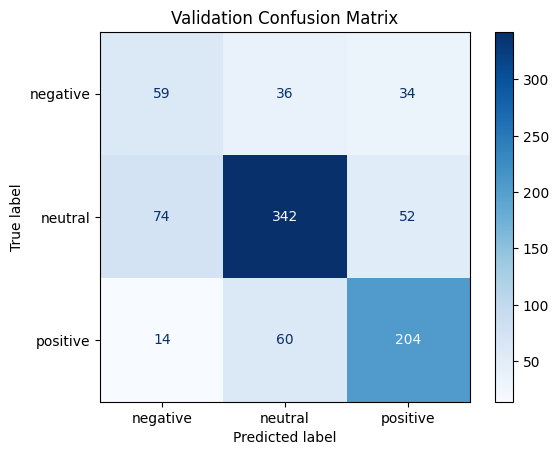

In [148]:
cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=lr_pipeline_final.named_steps["classifier"].classes_
)

disp.plot(cmap="Blues")
plt.title("Validation Confusion Matrix")
plt.show()